# <u>Lab Two - Classification</u>

Authors:  Muskaan Mahes, Chloe Prowse, Aayush Dalal, Nino Castellano

In [1]:
# Necessary imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 1) <u> Data Preparation </u>

### Define and Prepare Class Variables

The Student Placement Dataset from Kaggle was collected and analyzed to determine whether students’ results were sufficient to obtain a job offer. The dataset contained over 50,000 records consisting of academic, technical, and soft-skill attributes that can influence the outcome of being placed or not. <b>(This is our primary Classification Task #1)</b> Therefore, the primary purpose of the dataset is to help students, educational institutions, career centers understand which factors are crucial for achieving a successful placement outcome. 

We previously used this data to analyze and explore the relationships between students’ key features and their placement outcome to identify important insights. We then built and evaluated two classification models (SVM and Logistic Regression) to predict a student's placement status based on various academic, technical, and personal attributes. Now our objective is to take it a step further by training and evaluating different classification models for our existing classification task, Placement Status, while also training/evaluating those same models on a different classification task we can come up with from this data.

For example, as a <b>Secondary Classification Task #2 </b> aligned with our broader goal of understanding the factors that contribute to long-term career success, we could classify a student’s likelihood of securing an internship based on their current academic, technical, and personal attributes. Predicting internship attainment is particularly meaningful because internships often serve as a critical stepping stone toward full-time employment. By modeling internship probability, we can evaluate where a student currently stands in their professional development journey and identify areas for improvement. Since even a single internship can significantly increase the likelihood of receiving a full-time offer later, this secondary task provides both practical and predictive value alongside our primary placement classification objective.

Summarizing Clasification Tasks:

- <b>Placement Outcome (Yes or No) </b>
- <b>Internship Placement (Yes or No) </b>

Together, these two classification tasks create a developmental pathway: predicting internship probability drives short-term skill adjustments that increase immediate opportunities, and those strengthened skills directly feed into improved placement outcomes, ultimately supporting long-term full-time career success.

In [3]:
#loading dataset
df = pd.read_csv("/Users/muskaanmahes/Downloads/full_dataset.csv")
print(df.shape)
df.head()

(50000, 15)


,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


### Describe Final Dataset

Using our previously preprocessed from earlier labs which has already been cleaned, and verified to contain no missing values; the data is ready preprocessing using encoding and scaling and then for model training and testing. The only additional step required is to create a new encoded target variable, <b>Internship Placement</b>, derived from the <b>Internships</b> feature. Students with at least one internship will be labeled <b>Yes</b>, while those with none will be labeled <b>No</b>.

In [4]:
#dropping ID Because it is not useful for the model
df = df.drop(columns=["Student_ID"], errors='ignore')

# Create Internship Placement binary target variable
df["Internship_Placement"] = np.where(df["Internships"] >= 1, "Yes", "No")

#identifying numeric and categorical columns
numeric_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Verify the identified columns
print("Numeric Columns:", len(numeric_columns))
print(numeric_columns)
print("Categorical Columns:", len(categorical_columns))
print(categorical_columns)

Numeric Columns: 10
Index(['Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills',
       'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating',
       'Certifications', 'Backlogs'],
      dtype='object')
Categorical Columns: 5
Index(['Gender', 'Degree', 'Branch', 'Placement_Status',
       'Internship_Placement'],
      dtype='object')


In [5]:
print(df.shape)
df.head()

(50000, 15)


,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status,Internship_Placement
0,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed,No
1,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed,Yes
2,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed,Yes
3,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed,Yes
4,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed,Yes


## 2) <u> Modeling and Evaluation </u>

### Choosing and Explaining Evaluation Metrics

*Nino's Task: To Ellaborate more on Why we are using Precision for Evaluation*

### Method for Splitting Train and Test Sets

*Nino's Task: Explain the Splitting Criteria and Stratefied Fold*

In [6]:
# Encoding Placement_Status (Task 1)
le_task1 = LabelEncoder()
df["Placement_Status"] = le_task1.fit_transform(df["Placement_Status"])

# Encoding Internship_Placement (Task 2)
le_task2 = LabelEncoder()
df["Internship_Placement"] = le_task2.fit_transform(df["Internship_Placement"])

In [7]:
df.head()

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status,Internship_Placement
0,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,0,0
1,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,0,1
2,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,0,1
3,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,1,1
4,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,1,1


In [8]:
# Getting Test and Train Split for Task 1: Placement Status Classification
X_task1 = df.drop(columns=["Placement_Status", "Internship_Placement"])
y_task1 = df["Placement_Status"]

# Identify feature types AFTER dropping targets
numeric_columns_task1 = X_task1.select_dtypes(include=np.number).columns
categorical_columns_task1 = X_task1.select_dtypes(include="object").columns

# Preprocessor for Task 1
preprocessor_task1 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns_task1),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns_task1)
    ]
)

# Train Test Split
X_train_task1, X_test_task1, y_train_task1, y_test_task1 = train_test_split(
    X_task1,
    y_task1,
    test_size=0.3,
    random_state=42,
    stratify=y_task1
)

# Fit ONLY on train
X_train_task1 = preprocessor_task1.fit_transform(X_train_task1)
X_test_task1 = preprocessor_task1.transform(X_test_task1)

In [9]:
# Getting Test and Train Data for Task 2: Internship Placement Classification
X_task2 = df.drop(columns=[
    "Internship_Placement", # target variable for Task 2
    "Internships",          # used to create target
    "Placement_Status"      # logically happens after internship
])

y_task2 = df["Internship_Placement"]

X_train_task2, X_test_task2, y_train_task2, y_test_task2 = train_test_split(
    X_task2, y_task2,
    test_size=0.3,
    random_state=42,
    stratify=y_task2
)

# IMPORTANT:
# Recreate column lists for Task 2 (since we dropped features)

numeric_columns_task2 = X_task2.select_dtypes(include=np.number).columns
categorical_columns_task2 = X_task2.select_dtypes(include="object").columns

preprocessor_task2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns_task2),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns_task2)
    ]
)

X_train_task2 = preprocessor_task2.fit_transform(X_train_task2)
X_test_task2 = preprocessor_task2.transform(X_test_task2)

In [10]:
# Final Ready-to-Use Data
print("TASK 1 Ready Shapes:")
print(X_train_task1.shape, X_test_task1.shape)

print("\nTASK 2 Ready Shapes:")
print(X_train_task2.shape, X_test_task2.shape)

TASK 1 Ready Shapes:
(35000, 18) (15000, 18)

TASK 2 Ready Shapes:
(35000, 17) (15000, 17)


<u>Note on how to Plug and Play Test and Train Sets into Models</u>

Task 1 Train and Test Sets (Placement Status):
X_train_task1, X_test_task1, y_train_task1, y_test_task1

Task 2 Train and Test Sets (Internship Placement):
X_train_task2, X_test_task2, y_train_task2, y_test_task2

Instructions on How to Use:

1. Initialize model
2. Fit on train
3. Predict on test
4. Evaluate

Example Classifier for Task 1:

Initialize

- rf = RandomForestClassifier(random_state=42)

Train

- rf.fit(X_train_task1, y_train_task1)

Predict on test set

- y_pred_task1 = rf.predict(X_test_task1)

Evaluate

- print("Accuracy:", accuracy_score(y_test_task1, y_pred_task1))
- print(classification_report(y_test_task1, y_pred_task1))



### Three Different Classification/Regression Models



### Analyze XGBoost Model Results Using Choosen Evaluation Metric

In [38]:
### XGBoost Model 
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import precision_score, classification_report
from sklearn.metrics import PrecisionRecallDisplay
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


#Task 1: Placement outcome
# creates a stratified 10-CV with the XGBoost classifier object 
cv_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    tree_method="hist"
)

#hyperparameter tuning 
parameter_dist = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 5, 10],
    "gamma": [0, 0.5, 1, 2],
    "reg_lambda": [0.5, 1, 2, 5],
}

#randomized search for best hyperparamters
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=parameter_dist,
    n_iter=25,
    scoring="precision",
    cv=cv_10,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)
#train using the training data
search.fit(X_train_task1, y_train_task1)

#best model
best_xgb = search.best_estimator_
print("Best parameters:", search.best_params_)

#evaluate on the test set
y_pred_task1 = best_xgb.predict(X_test_task1)

print("Test Precision:", precision_score(y_test_task1, y_pred_task1))
print(classification_report(y_test_task1, y_pred_task1)) 

Fitting 10 folds for each of 25 candidates, totalling 250 fits
Best parameters: {'subsample': 0.9, 'reg_lambda': 5, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 2, 'colsample_bytree': 0.9}
Test Precision: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9563
           1       1.00      1.00      1.00      5437

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000



## Analyze Model Results Using Choosen Evaluation Metric For Task 1
        To model the first classification task, an XGBoost classifier was implmented. XGBoost was selected because it is a powerful learning method that build a series of decision trees sequentially, where each new tree attempts to correct errors made by previous ones. This boosting approach often leads to strong predictive performances. To further enhance performance, hyperparameters such as the number of trees, tree depth, learning rate, subsampling ratio, and regularization strength were optimixed using Randomized SearchCV with stratified 10-fold cross validation, using precision as the evaluation metrix. 
        The final tuned model achieved a test precision of 1.00, indicating that every student predicted to recieve a placement was correctly classified. The classification report also shows perfect recall and F1-scores for both classes, suggesting that the model was able to accurately seperate placed and non-placed students in the synthetic datasets. These perfect scores are likely due to the snythetic nature of the dataset, where relationships between features and placement outcomes are generated using clear patterns or rules. Because these relationships are highly structured, the XGBoost model is able to learn the underlying patterns very effectively and classify all observations correctly. 

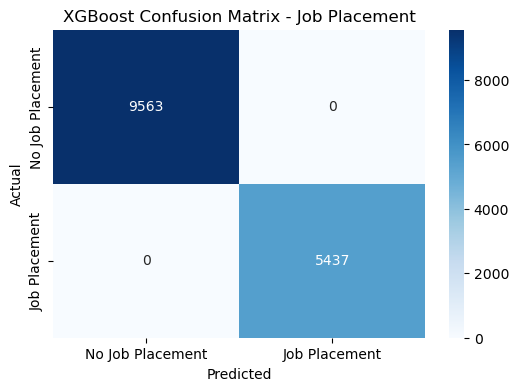

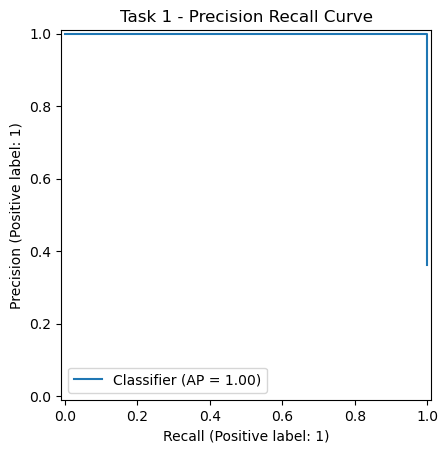

In [47]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
#confusion matrix 
y_pred_task1 = best_xgb.predict(X_test_task1)

cm = confusion_matrix(y_test_task1, y_pred_task1)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Job Placement", "Job Placement"],
    yticklabels=["No Job Placement", "Job Placement"]
)

plt.title("XGBoost Confusion Matrix - Job Placement")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Precision-recall curve plot
y_scores_task1 = best_xgb.predict_proba(X_test_task1)[:,1]

PrecisionRecallDisplay.from_predictions(
    y_test_task1,
    y_scores_task1
)

plt.title("Task 1 - Precision Recall Curve")
plt.show()

## Visualization of Results for Task 1
        To further evaluate the model's performance, two visualizations were generated a confusion matrix, and a precision-recall curve. The confusion matrix provides a detailed breakdown of the model's predictions by showing the number of true positives, true negatives, false positives. and false negatives. In this case, the matrix shows 9.563 true negatives and 5,437 true positives, with zero false positives and zero false negatives indicating that the model classified every observation correctly. This visualization is particular useful for understanding how the model performs across each class. 
        The precision-recall curve reinforces this result, as the curve remains at the top of the plot with an average precision score of 1,00, indicating perfect precision across nearly all recall values. 
        Additionally, since the dataset is synethetic and contains clear patterns between student attributes and placement outcomes, the model is able to capture these relationships perfectly, resulting in strong performance observed in both visualizations. 


In [40]:
#Task 2: Intership Placement

#10 fold CV and base XGBoost model
cv_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    tree_method="hist"
)

#hyperparameter tuning 
parameter_dist = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 5, 10],
    "gamma": [0, 0.5, 1, 2],
    "reg_lambda": [0.5, 1, 2, 5],
}

#randomized search for best hyperparamters
search_task2 = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=parameter_dist,
    n_iter=25,
    scoring="precision",
    cv=cv_10,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)
#train using the training data
search_task2.fit(X_train_task2, y_train_task2)

#best model
best_xgb_task2 = search_task2.best_estimator_
print("Best parameters:", search_task2.best_params_)

#evaluate on the test set
y_pred_task2 = best_xgb_task2.predict(X_test_task2)

print("Test Precision:", precision_score(y_test_task2, y_pred_task2))
print(classification_report(y_test_task2, y_pred_task2)) 



Fitting 10 folds for each of 25 candidates, totalling 250 fits
Best parameters: {'subsample': 0.9, 'reg_lambda': 5, 'n_estimators': 600, 'min_child_weight': 2, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 1, 'colsample_bytree': 0.8}
Test Precision: 0.7482308111050626
              precision    recall  f1-score   support

           0       0.66      0.73      0.69      6886
           1       0.75      0.68      0.71      8114

    accuracy                           0.70     15000
   macro avg       0.70      0.70      0.70     15000
weighted avg       0.71      0.70      0.70     15000



## Analyze Model Results Using Choosen Evaluation Metric For Task 2
        For task 2, which predicts whether a studnet will obtain an internship, the XGBoost model achieved a precision score of around 0.75 and an overall accuracy of 0.70 on the test set. This indicates that about 75% of the students predicted to obtain an intership were correctly classified, though the model still produced some false positives and false negatives. The classification report shows moderate performance across both classes, with F-1 scores around 0.69 to 0.71, suggesting that the model is balanced but not perfect. 
        Compared to task 1, task 2 is more complex because internship outcomes may depend on additional factos not captured in the dataset such as, interview performance or networking. Therefore, the model is able to identify general patterns in the data but cannot perfectly seperate the two classes. 

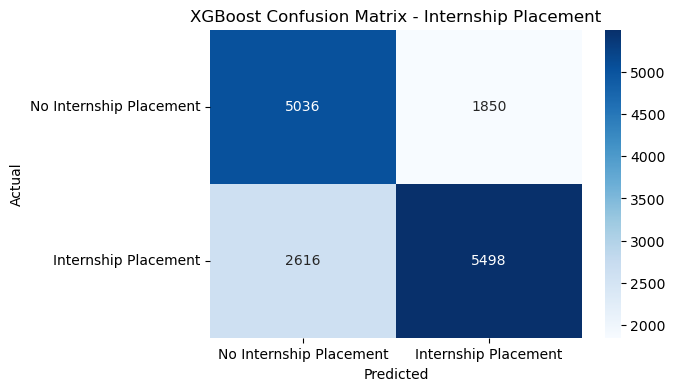

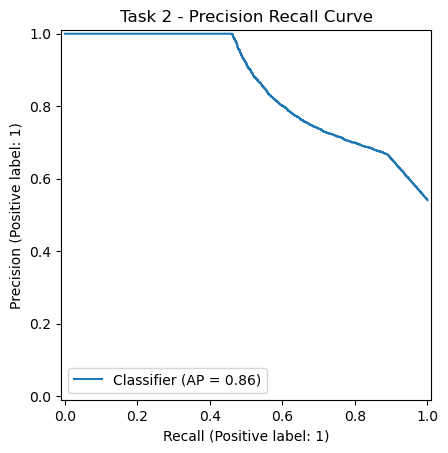

In [48]:
#confusion matrix: internship placement
y_pred_task2 = best_xgb_task2.predict(X_test_task2)

cm = confusion_matrix(y_test_task2, y_pred_task2)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Internship Placement", "Internship Placement"],
    yticklabels=["No Internship Placement", "Internship Placement"]
)

plt.title("XGBoost Confusion Matrix - Internship Placement")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#precision recall curve
y_scores_task2 = best_xgb_task2.predict_proba(X_test_task2)[:,1]

PrecisionRecallDisplay.from_predictions(
    y_test_task2,
    y_scores_task2
)

plt.title("Task 2 - Precision Recall Curve")
plt.show()

## Visualization of Results for Task 2
        For task 2, which predicts internships placement, the results were analyzed using a confusion matrix and a precision-recall curve. The confusion matrix shows that the model correctl predicted 5,036 true negatives meaning students who did not recieve internships, and 5,498 true positives meaning students who did recieve internships. Though, the model also produces 1,850 false positives and 2,616 false negatives, indicating that internship outcomes are harder to predict than placement outcomes.
        The precision-recall curve also illustrare this challenge, as it has an average precision score of 0.86. Unlike task 1, where precision was had perfect recall values, task 2 curve gradually declines as recall increases. This indicates that as the model attempts to indentify more students who will recieve internships, it begins to produce more false positives, which reduces precision. Therefore, using this model haves trade-offs when identifying more internships candiates and maintaining reliable predictions. 

### Discuss Advantages of Each Model on Each Classification/Regression Task
        For each classification task, each task demonstrated different strengths. The XGBoost had the strongest performance for task 1 as it achieved the perfect precision and recall value, which indicated that the boosting approach was able to capture the patterns in the synthethic dataset effectively. The XGBoost can perform well on tabular data becayse they can model complex nonlinear relationships and interactions between features.
        For task 2, the performance was lower indiciating that the problem is difficult because the features do not seperate the classes perfectly. Even though, the model shows different raw perfromance scores, statistical comparison methods such as the McNemar's Test can be used to determine whether the observed differences are statistically signficant at the 95% confidence level. Here, the XGBoost appears to perform better than simpler models, and the differences would need to be confirmed through statistical tests to determine whether the improvement is significant rather than due to sampling variation. 


### Which Attributes are Most Important for each Classification Task
        The attributes that were evaluated used the XGBoost model built in feature importance scores, which measures how frequent each attribute contribute to splitting the decision tree during training. Attributes such as CGPA, number of internships, coding skills, and projects were among the most influential predictors for the classification tasks. These attributes are important because they directly reflect a student's techincal ability, experience, and academic performance, which are key factors that employers consider when offering internships or full-time placements. In contrast, demographic attributes such as age or gender contribute less to the model decisions. Therefore, the results suggest that practical and technical experience play the biggest role in predicting both internship and placement outcome. 

## 3) <u> Deployment </u>

### Usefulness of Model to Interested Parties 

## 4) <u> Exceptional Work </u>


In [44]:
from sklearn.neighbors import KNeighborsClassifier

#Creating a KNN model for task 1
knn_task1 = KNeighborsClassifier(n_neighbors=5)

#train
knn_task1.fit(X_train_task1, y_train_task1)

#predict
y_predict_knn_task1 = knn_task1.predict(X_test_task1)

print("Task 1 KNN Precision:" , precision_score(y_test_task1, y_predict_knn_task1))
print(classification_report(y_test_task1, y_predict_knn_task1))


Task 1 KNN Precision: 0.892739559868307
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      9563
           1       0.89      0.95      0.92      5437

    accuracy                           0.94     15000
   macro avg       0.93      0.94      0.94     15000
weighted avg       0.94      0.94      0.94     15000



## Results for Task 1
        For task 1, the K-Nearest Neighbors model achieved a precision of about 0.89 and overall accuracy of 0.94, which indicates a strong performance in predicting student placement outcomes. The model performed well for negative class, with a precision of 0.97 and recall of 0.94. While the positive class achieved a precision of 0.89 and recall of 0.95. These results suggest that KNN is effective at identifying patterns in the dataset and can correctly classify most students as placed or not placed.

In [45]:
#Creating a KNN model for task 2
knn_task2 = KNeighborsClassifier(n_neighbors=5)

#train
knn_task2.fit(X_train_task2, y_train_task2)

#predict
y_predict_knn_task2 = knn_task2.predict(X_test_task2)

print("Task 2 KNN Precision:" , precision_score(y_test_task2, y_predict_knn_task2))
print(classification_report(y_test_task2, y_predict_knn_task2))



Task 2 KNN Precision: 0.7172387393135128
              precision    recall  f1-score   support

           0       0.65      0.68      0.66      6886
           1       0.72      0.69      0.70      8114

    accuracy                           0.69     15000
   macro avg       0.68      0.69      0.68     15000
weighted avg       0.69      0.69      0.69     15000



## Results for task 2
        For Task 2, the KNN model achieved a precision of around 0.72 and an overall accuracy of 0.69, indicating moderate predictive performance. Additionally, the model produced similar results across both classes, with F1-scores around 0.66 to 0.70, suggesting a balanced but less accurate classification compared to task 1. With a lower performance it reflects the increased diffculty of prediciting internship outcomes because these decisions can depend on additional factors not captured in the dataset. 
        Overall, this additional modeling experiments highlights how different algorithms respond to the dataset and emphasizes the importance of model strategies for predicting student internship and placement success. 

### Additional Model or Hyperparameter Tuning Via Grid Search